Вам предстоит решить задачу классификации сложных цветных изображений — датасет **CIFAR-10**.
В нем 10 классов: самолеты, автомобили, птицы, кошки, олени, собаки, лягушки, лошади, корабли, грузовики.

**Ваша цель:** Пробить "потолок" точности (`accuracy`) в **50%** на тестовой выборке.
**Главное правило:** Запрещено использовать любые слои, кроме `Dense`, `Dropout`, `Input` и слоев регуляризации. Никаких сверточных нейросетей (CNN)! Только полносвязные сети.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Вспомогательная функция для отрисовки графиков
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()

    plt.show()

На финальный прогон не оставлось ресурса GPU на гугл аккаунте поэтому финальный запуск был на CPU.

In [2]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

print(tf.config.list_physical_devices('GPU'))

Num GPUs Available: 0
[]


### Шаг 1: Загрузка и подготовка данных
Изображения цветные, размер 32x32 пикселя, 3 канала (RGB).
1. Загрузите датасет CIFAR-10.
2. "Распрямите" изображения (Flatten) в плоский вектор. Какова будет его размерность?
3. Масштабируйте данные (от 0 до 1).
4. Закодируйте метки классов (y) методом One-Hot Encoding.

1. Загрузите датасет CIFAR-10.

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("Исходные размерности:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Исходные размерности:
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


2. "Распрямите" изображения (Flatten) в плоский вектор. Какова будет его размерность?

In [4]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

theoretical_flatten_shape = 1
for num in X_train.shape[1:]:
    theoretical_flatten_shape *= num

print("После Flatten должна быть размерность: ", theoretical_flatten_shape)
print("Размерность после Flatten:")
print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

После Flatten должна быть размерность:  3072
Размерность после Flatten:
X_train_flat shape: (50000, 3072)
X_test_flat shape: (10000, 3072)


3. Масштабируйте данные (от 0 до 1).

In [5]:
print(f"Старый диапазон значений: {np.min(X_train_flat)} -- {np.max(X_train_flat)}")
X_train_flat = X_train_flat.astype("float32") / 255.0
X_test_flat = X_test_flat.astype("float32") / 255.0

print(f"Новый диапазон значений: {np.min(X_train_flat)} -- {np.max(X_train_flat)}")

Старый диапазон значений: 0 -- 255
Новый диапазон значений: 0.0 -- 1.0


4. Закодируйте метки классов (y) методом One-Hot Encoding.

In [6]:
num_classes = 10

y_train_ohe = keras.utils.to_categorical(y_train, num_classes)
y_test_ohe = keras.utils.to_categorical(y_test, num_classes)

print("\ny после One-Hot Encoding:")
print("y_train_ohe shape:", y_train_ohe.shape)
print("y_test_ohe shape:", y_test_ohe.shape)


y после One-Hot Encoding:
y_train_ohe shape: (50000, 10)
y_test_ohe shape: (10000, 10)


Выведем изображения из датасета:

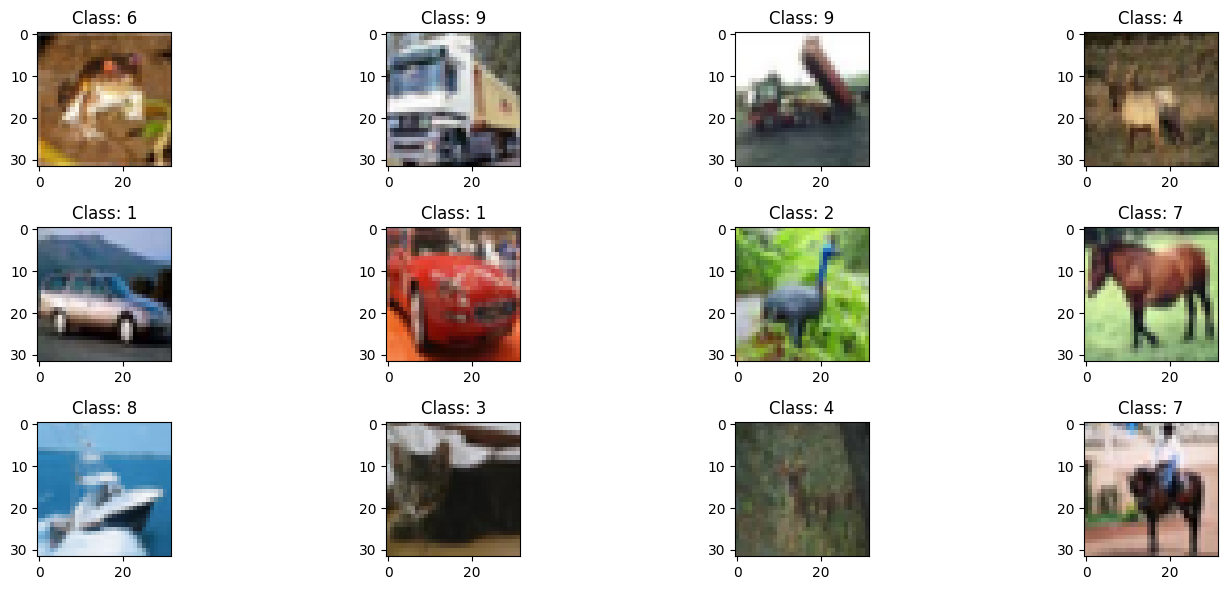

In [7]:
num_images = 12

plt.figure(figsize=(15, 6))

for i in range(num_images):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_train[i])

    plt.title(f"Class: {y_train[i][0]}")

plt.tight_layout()
plt.show()

### Шаг 2: Модель "Слабое звено" (Недообучение)
Давайте посмотрим, что будет, если дать сложной задаче слишком простую модель.
1. Создайте сеть всего с одним скрытым слоем на **32 нейрона** (активация `relu`).
2. Добавьте выходной слой. *Внимание! Подумайте, какая функция активации и loss-функция нужны для 10 классов.*
3. Обучите на 15 эпохах.
4. Постройте графики. Сделайте выводы: хватает ли емкости этой сети, чтобы уловить закономерности в цветных фото?

1. Создайте сеть всего с одним скрытым слоем на 32 нейрона (активация relu).
2. Добавьте выходной слой. Внимание! Подумайте, какая функция активации и loss-функция нужны для 10 классов.

Для выходного слоя берем softmax, т.к. решаем задачу многоклассовой классификации

In [8]:
model = keras.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(32, activation='relu'),

    layers.Dense(10, activation='softmax')
])

3. Обучите на 15 эпохах.

Компилируем модель и запускаем обучение на 15 эпохах с валидацией в 0.2 и батчами по 128

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train_flat,
    y_train_ohe,
    validation_split=0.2,
    epochs=15,
    batch_size=128,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        98,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,666 (385.41 KB)

 Trainable params: 98,666 (385.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1395 - loss: 2.2505 - val_accuracy: 0.1941 - val_loss: 2.1282
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2067 - loss: 2.0681 - val_accuracy: 0.2197 - val_loss: 2.0336
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2418 - loss: 2.0049 - val_accuracy: 0.2587 - val_loss: 1.9926
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2543 - loss: 1.9764 - val_accuracy: 0.2610 - val_loss: 1.9762
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2589 - loss: 1.9638 - val_accuracy: 0.2656 - val_loss: 1.9740
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2673 - loss: 1.9480 - val_accuracy: 0.2628 - val_loss: 1.9549
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2620 - loss: 1.9448 - val_accuracy: 0.2632 - val_loss: 1.9514
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2652 - loss: 1.9357 - val_accuracy: 

4. Постройте графики. Сделайте выводы: хватает ли емкости этой сети, чтобы уловить закономерности в цветных фото?

Выведем графики обучения и посмотрим на точность на тестовой выборке

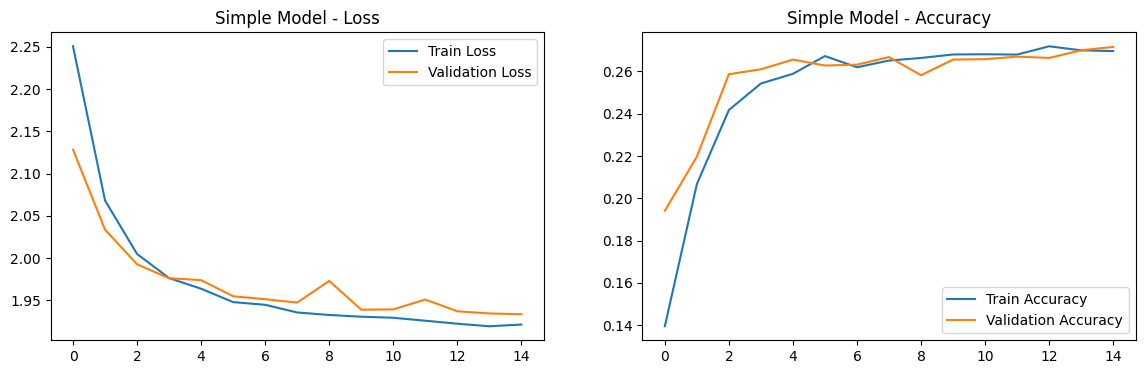


Test Accuracy: 0.2723
Test Loss: 1.9152


In [10]:
plot_history(history, "Simple Model")

test_loss, test_acc = model.evaluate(
    X_test_flat,
    y_test_ohe,
    verbose=0
)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

 Валидация не сильно расходится с трейном, что означает, что переобучение еще не наступило. Видно, что падение loss и рост accuracy на трейне затухли, не достигнув нормального качества, что означает, что модель почти не способна уловить закономерности в этих данных, а значит, емкости не хватает

### Шаг 3: Модель "Зубрила" (Переобучение)
Простая модель не справилась (метрики застряли на ~30%). Дадим сети больше мощности!
1. Постройте глубокую полносвязную сеть (например, скрытые слои на **1024, 512 и 256 нейронов**).
2. **Не используйте** Dropout или регуляризацию.
3. Обучите на 25 эпохах.
4. Постройте графики. **Вопрос для размышления:** На какой эпохе сеть перестала учиться обобщать и начала просто "зазубривать" тренировочные данные? Как вы это поняли по графику Loss?

1. Постройте глубокую полносвязную сеть (например, скрытые слои на 1024, 512 и 256 нейронов).
2. Не используйте Dropout или регуляризацию.

Соберем модель как сказано и скомпилируем:

In [11]:
model = keras.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

3. Обучите на 25 эпохах.

обучим на 25 эпохах с валидацией 0.2 и размером батча в 128

In [12]:
history = model.fit(
    X_train_flat,
    y_train_ohe,
    validation_split=0.2,
    epochs=25,
    batch_size=128,
    verbose=1
)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 90ms/step - accuracy: 0.2955 - loss: 1.9519 - val_accuracy: 0.3418 - val_loss: 1.8092
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.3890 - loss: 1.7097 - val_accuracy: 0.3992 - val_loss: 1.6831
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.4194 - loss: 1.6210 - val_accuracy: 0.4281 - val_loss: 1.6050
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 87ms/step - accuracy: 0.4446 - loss: 1.5540 - val_accuracy: 0.4309 - val_loss: 1.5888
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.4606 - loss: 1.5083 - val_accuracy: 0.4561 - val_loss: 1.5155
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - accuracy: 0.4783 - loss: 1.4621 - val_accuracy: 0.4445 - val_loss: 1.5478
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.4899 - loss: 1.4265 - val_accuracy: 0.4769 - val_loss: 1.4815
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.4993 - loss: 1.3998 - 

4. Постройте графики. Вопрос для размышления: На какой эпохе сеть перестала учиться обобщать и начала просто "зазубривать" тренировочные данные? Как вы это поняли по графику Loss?

Выведем графики обучения и посмотрим на точность на тестовой выборке

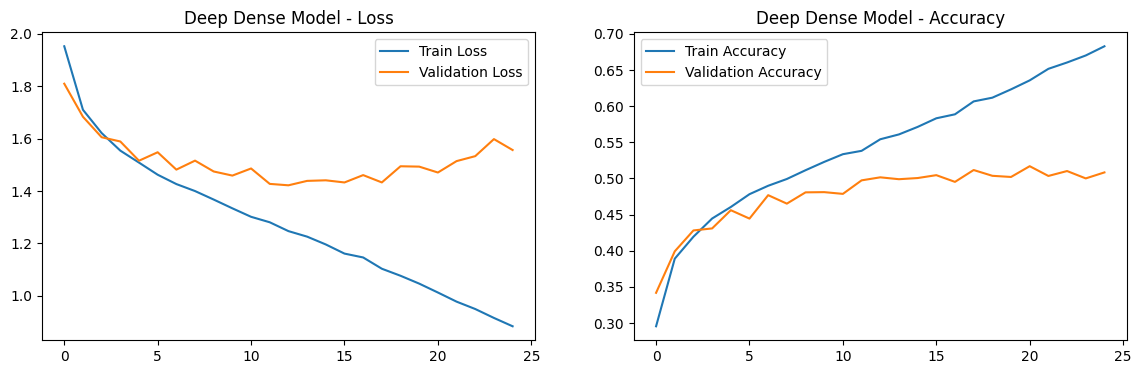


Test Accuracy: 0.5096
Test Loss: 1.5265


In [13]:
plot_history(history, "Deep Dense Model")


test_loss, test_acc = model.evaluate(
    X_test_flat,
    y_test_ohe,
    verbose=0
)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Модель начала переставать учиться обобщать примерно на 7-10 эпохе, когда лосс на валидации начал значимо расходиться с трейном, однако accuracy на валидации еще росло. Окончательно же модель начала зазубривать закономерности в трейне примерно около 15 эпох, когда лосс на валидации начал расти, а accuracy на валидации стала стогнировать.

Однако даже при всех этих недостатках, даже с такой простой архитектурой удалось пробить 50% точности

### Шаг 4: Вызываем подкрепление (Callbacks & Regularization)

Теперь применим весь арсенал. Создайте новую архитектуру, взяв за основу сеть из Шага 3, но добавив инструменты удержания:
1. **Dropout**: Добавьте слои `Dropout` (например, 0.3 или 0.4) после крупных `Dense` слоев.
2. **L2 Регуляризация**: (Опционально) добавьте `kernel_regularizer='l2'` в один из слоев.
3. **Callbacks**: При вызове метода `.fit()` передайте список из трех коллбэков:
   - `EarlyStopping`: остановка, если `val_accuracy` не растет 8 эпох (`restore_best_weights=False`, т.к. будем сохранять чекпоинтом).
   - `ReduceLROnPlateau`: уменьшение learning rate (factor=0.5), если метрика застряла на плато на 3 эпохи.
   - `ModelCheckpoint`: сохраняйте **только лучшие** веса в файл `best_cifar10_model.keras`.
4. Запустите обучение на 70 эпох. Коллбэки сами остановят процесс в нужный момент.

1. Dropout: Добавьте слои Dropout (например, 0.3 или 0.4) после крупных Dense слоев.
2. L2 Регуляризация: (Опционально) добавьте kernel_regularizer='l2' в один из слоев.

Добавим нужные слои и скомпилируем модель. Dropout сспециально взят ниже, чем было указано в задании, т.к. с dropout=0.3 модели не хватало емкости, чтобы пробить accuracy = 0.5

In [14]:
model = keras.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(
        1024,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4)
    ),
    layers.Dropout(0.2),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

optimizer = keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

3. Callbacks

Добавим нужные коллбеки (patience и другие параметры брались исходя из нескольких итераций обучений, чтобы модель не переобучалась)

In [15]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=False,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath='best_cifar10_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

4. Запустите обучение на 70 эпох. Коллбэки сами остановят процесс в нужный момент.

Запускаем обучение с коллбеками на 70 эпох. Также выведем грпафики обучения

Epoch 1/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.2113 - loss: 2.3044
Epoch 1: val_accuracy improved from None to 0.35050, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 106ms/step - accuracy: 0.2711 - loss: 2.1040 - val_accuracy: 0.3505 - val_loss: 1.8861 - learning_rate: 0.0010
Epoch 2/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3415 - loss: 1.8948
Epoch 2: val_accuracy improved from 0.35050 to 0.36120, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.3473 - loss: 1.8711 - val_accuracy: 0.3612 - val_loss: 1.8178 - learning_rate: 0.0010
Epoch 3/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3629 - loss: 1.8045
Epoch 3: val_accuracy improved from 0.36120 to 0.39550, saving model to best_cifar10_model.keras

Epoch 3: finished saving model to best_cif

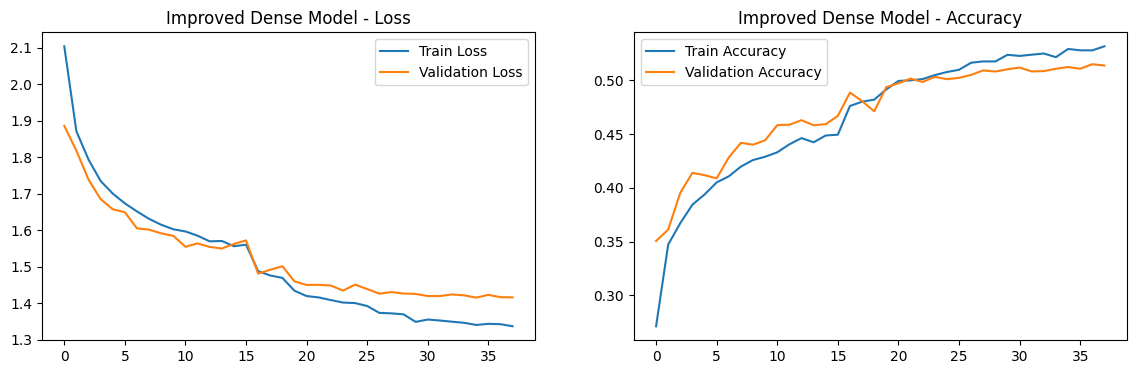

In [16]:
history = model.fit(
    X_train_flat,
    y_train_ohe,
    validation_split=0.2,
    epochs=70,
    batch_size=128,
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ],
    verbose=1
)

plot_history(history, "Improved Dense Model")

Видим, что модель вовремя остановилась благодаря коллбеку ранней остановки и не дошла до сильного переобучения. Также в процессе обучения несколько раз был снижен learning rate для продолжения скатывания в минимум. При этом и на трейне и на валидации модель пробила 50% точности

### Шаг 5: Оценка результата
1. Загрузите лучшие веса из сохраненного файла (`keras.models.load_model`).
2. Сделайте `.predict()` на тестовой выборке (`X_test`).
3. Выведите итоговое значение `accuracy_score`. Смогли ли вы преодолеть барьер в 50%?
4. Напишите краткий вывод: какой инструмент по вашему мнению оказал наибольшее влияние на результат?

1. Загрузите лучшие веса из сохраненного файла (keras.models.load_model).

In [17]:
best_model = keras.models.load_model('best_cifar10_model.keras')

2. Сделайте .predict() на тестовой выборке (X_test).

Делаем предикт и переводим вероятности в классы

In [18]:
y_pred_proba = best_model.predict(X_test_flat)

y_pred = np.argmax(y_pred_proba, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


3. Выведите итоговое значение accuracy_score. Смогли ли вы преодолеть барьер в 50%?

In [20]:
y_true = y_test.flatten()
test_accuracy = accuracy_score(y_true, y_pred)

if test_accuracy >= 0.5:
    print("УРА!!!!! Мы смогли преодолеть барьер в 50% точности!")
    print(f"Test Accuracy: {test_accuracy:.4f}")
else:
    print("Надо менять что то в обучении, точность всего ", test_accuracy)

УРА!!!!! Мы смогли преодолеть барьер в 50% точности!
Test Accuracy: 0.5155


4. Напишите краткий вывод: какой инструмент по вашему мнению оказал наибольшее влияние на результат?

Т.к. на предыдущем этапе с зазубривающей моделью уже был пробит порог в 50% точности, то можно заключить, что добавление регуляризации, дропаутов, и снижение learning rate позволили улучшить качество только на 1.5%, при чем dropout слои требовали длительного подбора своих значений, т.к. архитектуре и так не хватало емкости, чтобы запомнить закономерности в данных.

Однако с помощью коллбеков и дропаутов ужалось научить модель не переобучаться, даже к 40 эпохе, в то время как на предыдущем этапе модель уже переобучалась к 10 эпохе. Также был очень полезен механизм ранней остановки, позволивывший остановить обучении заранее, не достигая переобучения.


Итого, если сравнивать с начальной слабой моделью, лучший буст по качеству дало увеличение емкости модели на этапе зазубривания и доработка этой архитектуры для противодействия переобучению с помощью дропаутов и коллбеков.